### Copyright Matlantis Corp. as contributors to Matlantis contrib project

[JP]
##  ポリマーの自由体積計算
- シミュレーションは[こちらの論文](https://www.mdpi.com/2079-3197/7/2/27)を参考に実装した。
- 本notebookでは緩和した構造からAvailable Free Volume(AFV)を計算する。

[EN]
##  Calculation of Polymer Free Volume
- The simulation was implemented based on [this paper](https://www.mdpi.com/2079-3197/7/2/27)
- This notebook aims to compute the Available Free Volume (AFV) based on the relaxed system.

In [1]:
from ase import Atoms, units
from ase.data import vdw_radii, atomic_numbers
from ase.io import read, Trajectory
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree
%config InlineBackend.figure_format = 'retina'

def calc_density_g_cm3(atoms: Atoms) -> float:
    mass_g = atoms.get_masses().sum() / (units.kg / 1000)
    vol_cm3 = atoms.get_volume() / (units.m/100) **3
    return mass_g / vol_cm3

def view_results(traj_file, time_step=1, log_interval=100, use_ratio=10):
    
    # read output
    traj = Trajectory(traj_file)
    
    # calc properties
    time_interval = time_step * log_interval / 1000 # ps
    time_ps = [i * time_interval for i in range(len(traj))]

    vol, dens, pot, temp = [], [], [], []
    for atoms in traj:
        vol.append(atoms.get_volume())
        dens.append(calc_density_g_cm3(atoms))
        pot.append(atoms.get_potential_energy())
        temp.append(atoms.get_temperature())
    
    start = int(len(traj) * (1 - use_ratio/100))
    ave_density = np.mean(dens[start:])
    
    # visualize
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    fig.suptitle('Molecular Dynamics Simulation Analysis', fontsize=16)
    
    ax = axes[0, 0]
    ax.plot(time_ps, vol, label='Volume', color='royalblue')
    ax.set_ylabel('Volume (Å³)')
    ax.grid()
    ax.set_title('Volume vs Time (ps)')
    
    ax = axes[0, 1]
    ax.plot(time_ps, dens, label='Density', color='royalblue')
    ax.set_ylabel('Density (g/cm3)')
    ax.grid()
    ax.set_title('Density vs Time (ps)')
    
    ax = axes[1, 0]
    ax.plot(time_ps, pot, label='Potential Energy', color='royalblue')
    ax.set_ylabel('Potential Energy (eV)')
    ax.grid()
    ax.set_title('Potential Energy vs Time (ps)')
    
    ax = axes[1, 1]
    ax.plot(time_ps, temp, label='Temperature', color='royalblue')
    ax.set_ylabel('Temperature (K)')
    ax.grid()
    ax.set_title('Temperature vs Time (ps)')
    
    for ax in axes.flat:
        ax.set_xlabel('Time (ps)')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

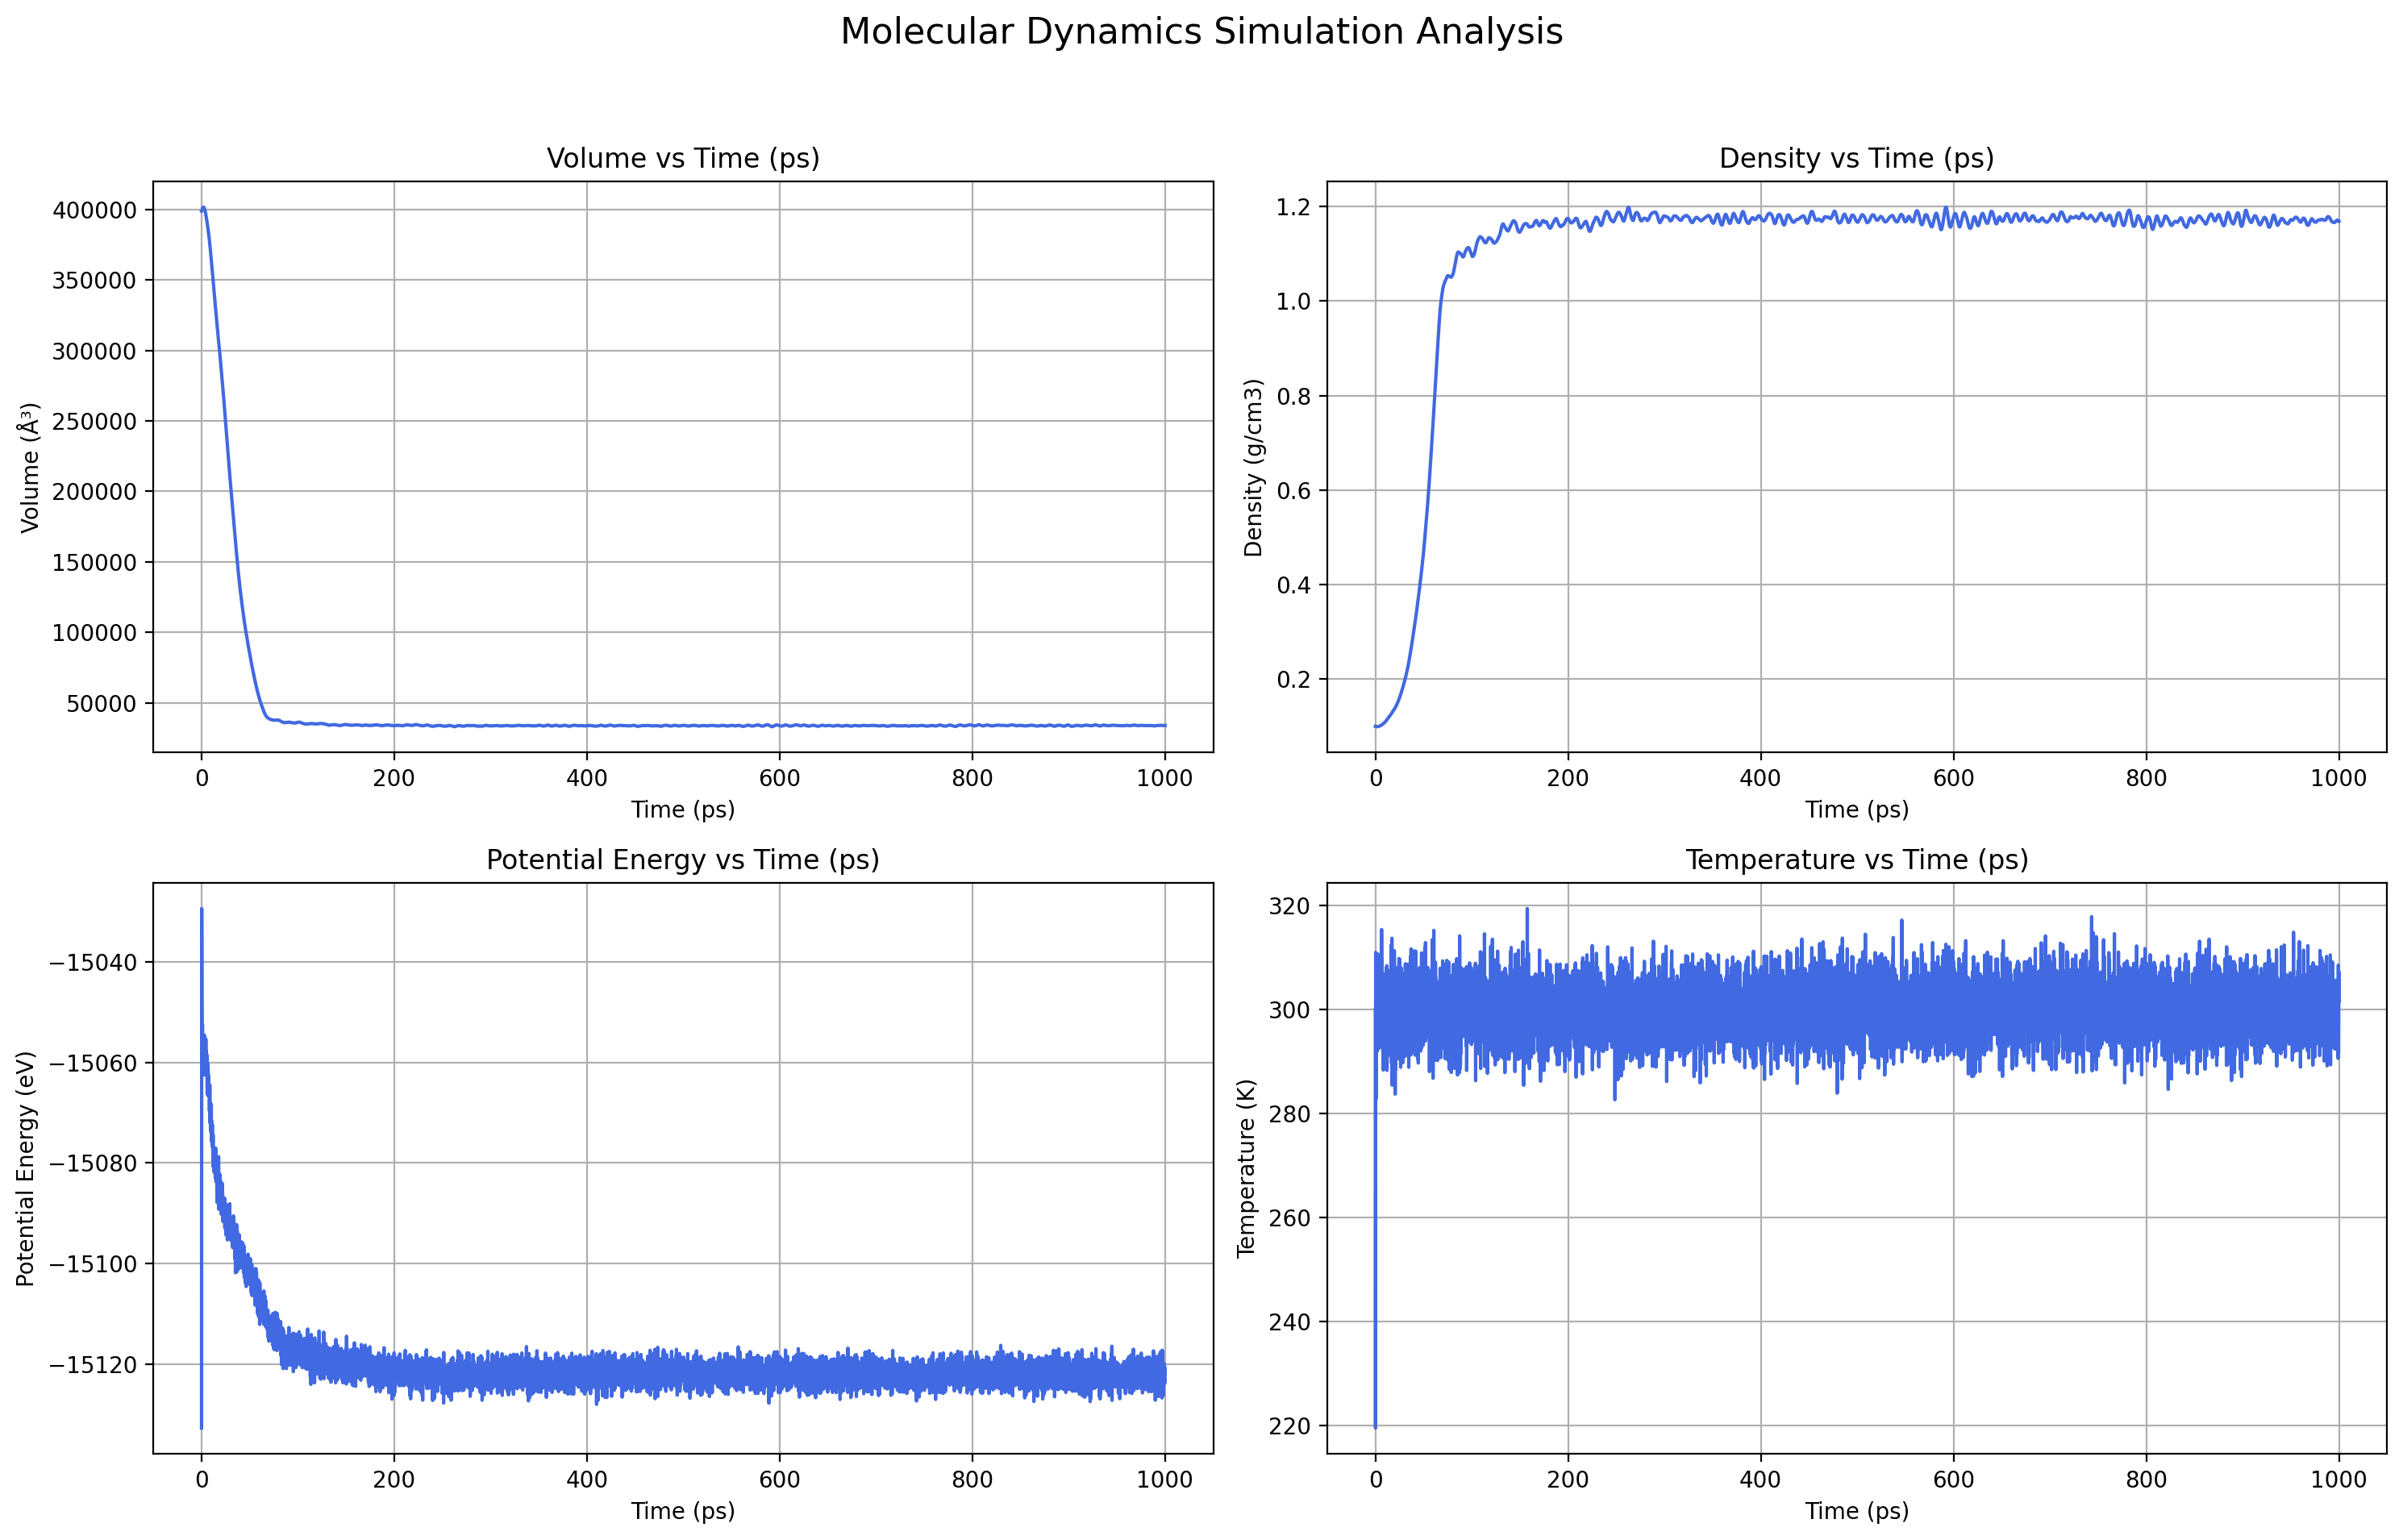

In [2]:
traj_file_UItem = "output_nPT/UItem_liq_20260209_153208/nPT_NoseHoover_ParrinelloRahman.traj"
view_results(traj_file_UItem)

In [3]:
atoms = Trajectory(traj_file_UItem)[-1]
atoms.wrap()

In [4]:
def get_ase_vdw_radius(symbol):
    """
    Retrieves the VDW radius from the ASE database.
    """
    number = atomic_numbers.get(symbol)
    r = vdw_radii[number]
    return r

def calculate_free_volume(atoms, probe_radius=0.0, grid_resolution=100, k_neighbors=3):
    """
    Free volume calculation using ASE VDW radii.
    
    Parameters:
    -----------
    atoms : ase.Atoms
        Target atomic structure.
    probe_radius : float or list of floats
        Radius of the probe particle(s) in Angstroms. 
        Can be a single float or a list of floats.
    grid_resolution : int
        Number of grid divisions along each axis.
    k_neighbors : int
        Number of nearest neighbors to search for.
        
    Returns:
    --------
    float or list of floats
        Free Volume (%). 
        Returns a single float if probe_radius is a scalar, 
        or a list of floats if probe_radius is a list.
    """
    
    # 1. Create grid (dot product is used to support non-orthogonal cells)
    cell = atoms.get_cell()
    
    nx, ny, nz = grid_resolution, grid_resolution, grid_resolution
    # Create fractional coordinates from 0 to 1
    gx, gy, gz = np.meshgrid(
        np.linspace(0, 1, nx, endpoint=False),
        np.linspace(0, 1, ny, endpoint=False),
        np.linspace(0, 1, nz, endpoint=False),
        indexing='ij'
    )
    
    # Convert to an (N, 3) array
    grid_frac = np.column_stack((gx.ravel(), gy.ravel(), gz.ravel()))
    
    # Convert to Cartesian coordinates (grid_frac @ cell)
    # This ensures the grid is evenly distributed inside the cell, even if it is distorted
    grid_cartesian = np.dot(grid_frac, cell)
    
    # 2. Handle Periodic Boundary Conditions (PBC)
    # First, create a list of VDW radii for the target atoms
    atom_radii_list = np.array([get_ase_vdw_radius(atom.symbol) for atom in atoms])

    # Create 27 images using combinations of -1, 0, 1 (considering PBC)
    # This allows grid points near the cell boundaries to correctly recognize "atoms in neighboring cells"
    shifts = []
    for i in [-1, 0, 1]:
        for j in [-1, 0, 1]:
            for k in [-1, 0, 1]:
                shift_vec = i * cell[0] + j * cell[1] + k * cell[2]
                shifts.append(shift_vec)
    
    # Shift all atoms to create a larger array
    original_positions = atoms.get_positions()
    
    # Accelerate using numpy broadcasting instead of loops
    shifts = np.array(shifts)  # (27, 3)
    # original (N, 3) + shifts (27, 1, 3) -> (27, N, 3) -> reshape -> (27*N, 3)
    pos_expanded = (original_positions[np.newaxis, :, :] + shifts[:, np.newaxis, :]).reshape(-1, 3)
    
    # Repeat the radii the same number of times
    radii_expanded = np.tile(atom_radii_list, 27)
    
    # 3. Search for nearest neighbor atoms (KDTree)
    # We don't use boxsize; instead, we search against the physically expanded atom group
    tree = cKDTree(pos_expanded)
    
    # Calculate the distance from each grid point to the nearest "expanded atoms"
    distances, atom_indices = tree.query(grid_cartesian, k=k_neighbors)
    
    # Retrieve the VDW radii of the obtained neighbor atoms (Grid count, k_neighbors)
    neighbor_radii = radii_expanded[atom_indices]
    
    n_total = len(grid_cartesian)
    
    # --- Check if probe_radius is a single value or an iterable (list/array) ---
    is_single_value = isinstance(probe_radius, (int, float))
    radii_list = [probe_radius] if is_single_value else probe_radius
    
    fv_results = []
    
    # Calculate AFV for each probe radius
    for r in radii_list:
        # 4. Occupancy check
        # Condition: distance < (atom radius + probe radius)
        collisions = distances < (neighbor_radii + r)
        
        # If any of the neighbors are in contact, the grid point is considered "occupied"
        # axis=1 groups the check across the k_neighbors direction
        is_occupied = np.any(collisions, axis=1)

        # 5. Aggregation
        n_free = np.sum(~is_occupied)
        fv_percent = (n_free / n_total) * 100.0
        fv_results.append(fv_percent)
    
    # Return a single float if a single float was passed, otherwise return a list
    return fv_results[0] if is_single_value else fv_results

In [5]:
probe_radiuses = np.linspace(0., 3., 30)
fv_list = calculate_free_volume(atoms, probe_radius=probe_radiuses)

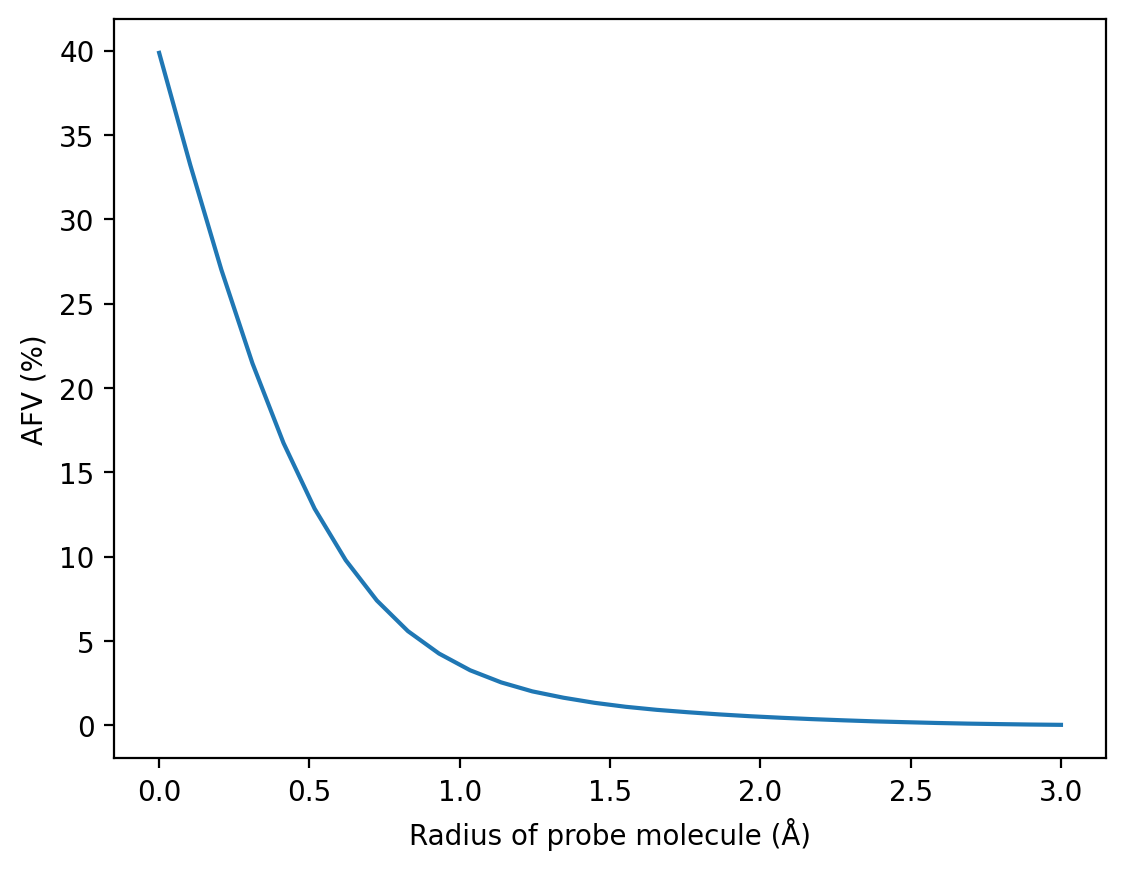

In [6]:
plt.plot(probe_radiuses, fv_list)
plt.xlabel("Radius of probe molecule (Å)")
plt.ylabel("AFV (%)")
plt.show()

In [7]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Wed, 25 Feb 2026

Python implementation: CPython
Python version       : 3.13.8
IPython version      : 9.7.0

ase       : 3.27.0
matplotlib: 3.10.8
numpy     : 2.2.6
scipy     : 1.16.3

Watermark: 2.6.0

